<a href="https://colab.research.google.com/github/youkjang/gefs-heavy-precip-verification/blob/main/notebooks/03_brier_score_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NOAA GEFS Precipitation
###Open data & Plot GEFS accumulatd precipitation

- data: https://psl.noaa.gov/thredds/catalog/catalog.html

##1. Install packages

In [1]:
!pip install cartopy

In [2]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

##2. Import Libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs
from pathlib import Path
import cartopy.crs as ccrs

##3. Set GEFS case information
- control + 10 perturbed memebrs

In [4]:
init_date = "20260520"   # YYYYMMDD
cycle = "00"             # GEFS cycle: 00, 06, 12, 18 UTC
fhr = 24                 # forecast hour
threshold_mm = 25       # heavy precipitation threshold

members = ["c00"] + [f"p{i:02d}" for i in range(1, 11)]  # 11 member ensemble


cache_dir = Path("/content/gefs_precip_cache")
cache_dir.mkdir(exist_ok=True);

Path("figures").mkdir(exist_ok=True);

fs = s3fs.S3FileSystem(anon=True)

##4. Function to open GEFS precipitation

In [5]:
def open_gefs_precip_member(init_date, cycle, member, fhr):
    """
    Open GEFS accumulated precipitation for one member and one forecast hour.
    Returns CONUS accumulated precipitation in mm.
    """

    fname = f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"

    s3_key = (
        f"noaa-gefs-pds/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/"
        f"{fname}"
    )

    local_file = cache_dir / fname

    if not local_file.exists():
        print(f"Downloading {fname}")
        fs.get(s3_key, str(local_file))
    else:
        print(f"Using cached file: {fname}")

    ds = xr.open_dataset(
        local_file,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {
                "typeOfLevel": "surface",
                "stepType": "accum"
            },
            "indexpath": ""
        }
    )

    if "tp" not in ds.data_vars:
        raise ValueError(f"'tp' not found. Available variables: {list(ds.data_vars)}")

    precip = ds["tp"]

    # Convert longitude from 0–360 to -180–180
    precip = precip.assign_coords(
        longitude=((precip.longitude + 180) % 360) - 180
    ).sortby("longitude")

    # Subset CONUS
    if precip.latitude[0] > precip.latitude[-1]:
        precip_us = precip.sel(
            longitude=slice(-125, -66),
            latitude=slice(50, 24)
        )
    else:
        precip_us = precip.sel(
            longitude=slice(-125, -66),
            latitude=slice(24, 50)
        )

    precip_us = precip_us.squeeze()
    precip_us.attrs["units"] = "mm"
    precip_us.attrs["long_name"] = "Accumulated precipitation"

    return precip_us

##5. Load multiple ensemble members

In [6]:
precip_members = []

for member in members:
    print(f"Opening member: {member}")

    da = open_gefs_precip_member(
        init_date=init_date,
        cycle=cycle,
        member=member,
        fhr=fhr
    )

    da = da.expand_dims(member=[member])
    precip_members.append(da)

precip_ens = xr.concat(precip_members, dim="member")


Opening member: c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening member: p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening member: p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening member: p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening member: p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening member: p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening member: p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening member: p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening member: p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening member: p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening member: p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024


/tmp/ipykernel_26266/2354021617.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  precip_ens = xr.concat(precip_members, dim="member")


##6. Compute GEFS probability of heavy precipitaiton

In [7]:
heavy_event_fcst = precip_ens >= threshold_mm
prob_heavy = heavy_event_fcst.mean(dim="member")

prob_heavy.attrs["units"] = "%"
prob_heavy.attrs["long_name"] = f"Probability of precipitation ≥ {threshold_mm} mm"

In [8]:
prob_heavy_percent = prob_heavy * 100.0

##7. Plot GEFS probability map

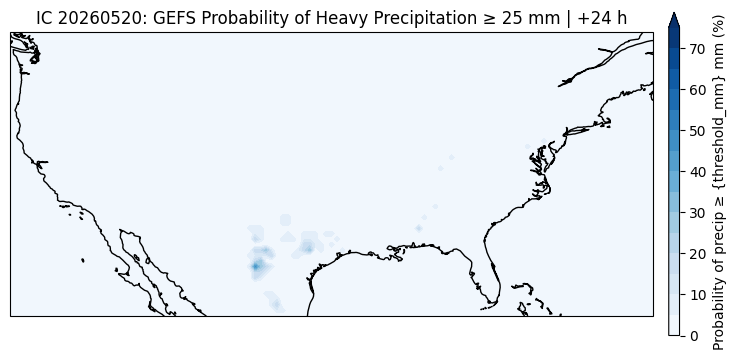

In [9]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = prob_heavy_percent

contour_levels_temp = np.arange(0, 80, 5)
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='max')

ax.coastlines()

# Add title and colorbar, then show the plot
plt.title(f"IC {init_date}: GEFS Probability of Heavy Precipitation ≥ {threshold_mm:.0f} mm | +{fhr} h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(cs_temp, label="Probability of precip ≥ {threshold_mm} mm (%)",
             pad=0.02, aspect=30,shrink=0.7)

plt.savefig("gefs_probability_heavy_precip_10mm_24h.png", dpi=150, bbox_inches="tight")

plt.show()

##8. Load observed precipitatoin

In [10]:
valid_time = pd.to_datetime(init_date, format="%Y%m%d") + pd.Timedelta(hours=fhr)
valid_date = valid_time.strftime("%Y-%m-%d")
year = valid_time.year

print("Forecast valid date:", valid_date)

Forecast valid date: 2026-05-21


In [11]:
#obs_url = f"https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_us_precip/RT/precip.V1.0.{year}.nc"

#obs_ds = xr.open_dataset(obs_url)
obs_ds = xr.open_dataset('precip.V1.0.2026.nc')

##9. Select observed precipitation for the valid date

In [12]:
obs_day = obs_ds.precip.sel(time=valid_date)

##10. Standardize observed longitude and subset CONUS

In [13]:
# Convert longitude if needed
if obs_day.lon.max() > 180:
    obs_day = obs_day.assign_coords(
        lon=((obs_day.lon + 180) % 360) - 180
    ).sortby("lon")

# Subset CONUS
if obs_day.lat[0] > obs_day.lat[-1]:
    obs_us = obs_day.sel(
        lon=slice(-125, -66),
        lat=slice(50, 24)
    )
else:
    obs_us = obs_day.sel(
        lon=slice(-125, -66),
        lat=slice(24, 50)
    )

obs_us

<xarray.DataArray 'precip' (lat: 104, lon: 236)> Size: 98kB
[24544 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 416B 24.12 24.38 24.62 24.88 ... 49.38 49.62 49.88
  * lon      (lon) float32 944B -124.9 -124.6 -124.4 ... -66.62 -66.38 -66.12
    time     datetime64[ns] 8B 2026-05-21
Attributes:
    long_name:                Daily Accumulated Precipitation
    units:                    mm
    precision:                2
    least_significant_digit:  2
    var_desc:                 Precipitation
    dataset:                  CPC Unified Gauge-Based Analysis of Daily Preci...
    level_desc:               Surface
    statistic:                Daily Accumulation
    parent_stat:              Observation
    valid_range:              [  0. 700.]
    actual_range:             [  0.      167.54831]

##11. Interpolate observations to GEFS grid

In [14]:
obs_us = obs_us.rename({"lat": "latitude", "lon": "longitude"})

In [15]:
obs_on_gefs = obs_us.interp(
    latitude=prob_heavy.latitude,
    longitude=prob_heavy.longitude
)

obs_on_gefs

<xarray.DataArray 'precip' (latitude: 53, longitude: 119)> Size: 50kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * latitude    (latitude) float64 424B 50.0 49.5 49.0 48.5 ... 25.0 24.5 24.0
  * longitude   (longitude) float64 952B -125.0 -124.5 -124.0 ... -66.5 -66.0
    time        datetime64[ns] 8B 2026-05-21
    step        timedelta64[ns] 8B 1 days
    surface     float64 8B 0.0
    valid_time  datetime64[ns] 8B 2026-05-21
Attributes:
    long_name:                Daily Accumulated Precipitation
    units:                    mm
    precision:                2
    least_significant_digit:  2
    var_desc:                 Precipitation
    dataset:                  CPC Unified Gauge-Based Analysis of Daily Preci...
    level_desc:               Surface
    statistic:                Daily Accumulation
    parent_stat:              Observation
    valid_range:              [  0. 700.]
    actual_range:             [  0.      167.54831]

##Observed Precipitation

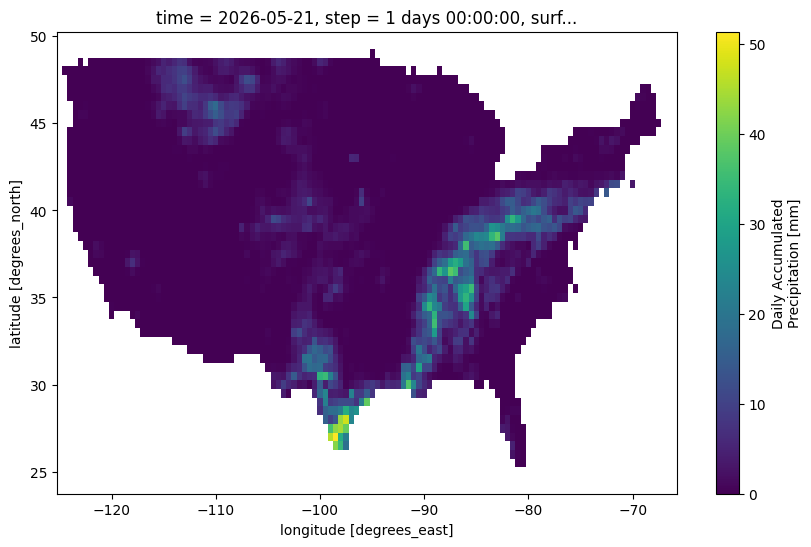

In [16]:
plt.figure(figsize=(10,6))
obs_on_gefs.plot()


##12. Create observed heavy precipitation event
True  = observed heavy precipitation occurred

False = observed heavy precipitation did not occur

In [17]:
obs_event = obs_on_gefs >= threshold_mm

obs_event.attrs["long_name"] = f"Observed precipitation ≥ {threshold_mm} mm"
obs_event

<xarray.DataArray 'precip' (latitude: 53, longitude: 119)> Size: 6kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * latitude    (latitude) float64 424B 50.0 49.5 49.0 48.5 ... 25.0 24.5 24.0
  * longitude   (longitude) float64 952B -125.0 -124.5 -124.0 ... -66.5 -66.0
    time        datetime64[ns] 8B 2026-05-21
    step        timedelta64[ns] 8B 1 days
    surface     float64 8B 0.0
    valid_time  datetime64[ns] 8B 2026-05-21
Attributes:
    long_name:                Observed precipitation ≥ 25 mm
    units:                    mm
    precision:                2
    least_significant_digit:  2
    var_desc:                 Precipitation
    dataset:                  CPC Unified Gauge-Based Analysis of Daily Preci...
    level_desc:               Surface
    statistic:                Daily Accumulation
    parent_stat:              Observation
    valid_range:              [  0. 700.]
    actual_range:             [  0.      167.54831]

Convert to 0/1 for Brier Score:

In [18]:
obs_event_numeric = obs_event.astype(float)

##13. Compute Brier Score

Brier Score = (forecast probability - observed event)^2

- forecast probability = 0 to 1
- observed event = 0 or 1

In [19]:
brier_score = (prob_heavy - obs_event_numeric) ** 2

brier_score.attrs["long_name"] = f"Brier Score for precipitation ≥ {threshold_mm} mm"
brier_score.attrs["units"] = "unitless"

brier_score

<xarray.DataArray (latitude: 53, longitude: 119)> Size: 50kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * latitude    (latitude) float64 424B 50.0 49.5 49.0 48.5 ... 25.0 24.5 24.0
  * longitude   (longitude) float64 952B -125.0 -124.5 -124.0 ... -66.5 -66.0
    step        timedelta64[ns] 8B 1 days
    surface     float64 8B 0.0
    valid_time  datetime64[ns] 8B 2026-05-21
Attributes: (12/40)
    GRIB_paramId:                             228228
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    statistic:                                Daily Accumulation
    parent_stat:                              Observation
    valid_range:                              [  0. 700.]
    actual_range:                             [  0.      167.54831]
    long_name:                                Brier Score for precipitation ≥...
    units:                                    unitless

Domain mean:

In [20]:
weights = np.cos(np.deg2rad(brier_score.latitude))
weights.name = "weights"

mean_brier_score = brier_score.weighted(weights).mean(
    dim=("latitude", "longitude")
)

print(f"CONUS-averaged Brier Score: {float(mean_brier_score.values):.3f}")

CONUS-averaged Brier Score: 0.007


##14. Plot observed heavy precipitation event

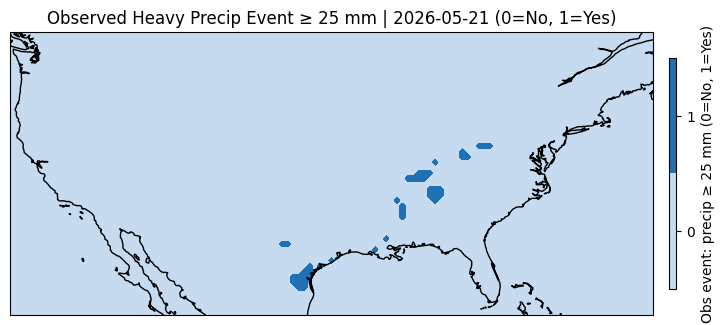

In [21]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = obs_event_numeric

# Fix 1: Correct contour levels for binary data (0 and 1)
# We need 3 levels to define 2 filled regions for 0s and 1s.
contour_levels_temp = [-0.5, 0.5, 1.5]
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='neither')

ax.coastlines()

# Fix 2: Update title to reflect observed event
plt.title(f"Observed Heavy Precip Event ≥ {threshold_mm:.0f} mm | {valid_date} (0=No, 1=Yes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Fix 3: Update colorbar label to reflect observed event (0 or 1)
plt.colorbar(cs_temp, label=f"Obs event: precip ≥ {threshold_mm:.0f} mm (0=No, 1=Yes)",
             ticks=[0, 1],
             pad=0.02, aspect=30,shrink=0.5)

plt.savefig("obs_heavy_precip_25mm.png", dpi=150, bbox_inches="tight")

plt.show()

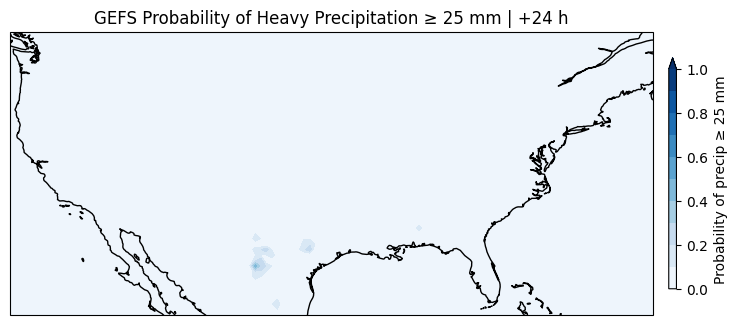

In [22]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = prob_heavy

# Fix 1: Correct contour levels for probability (0 to 1) and ensure they are increasing
contour_levels_temp = np.arange(0, 1.1, 0.1)
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='max')

ax.coastlines()

# Fix 2: Update title to reflect GEFS probability
plt.title(f"GEFS Probability of Heavy Precipitation ≥ {threshold_mm:.0f} mm | +{fhr} h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Fix 3: Update colorbar label to reflect GEFS probability
plt.colorbar(cs_temp, label=f"Probability of precip ≥ {threshold_mm:.0f} mm",
             pad=0.02, aspect=30,shrink=0.5)

#plt.savefig("gefs_probability_heavy_precip_25mm_24h.png", dpi=150, bbox_inches="tight")

plt.show()

##15. Plot Brier Score map

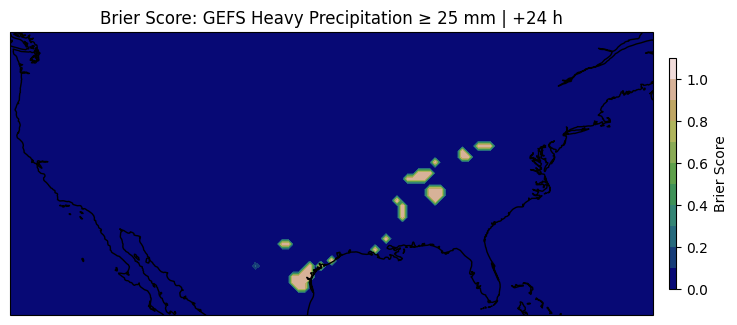

In [24]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = brier_score

# Fix 1: Correct contour levels for brier score (0 to 1) and ensure they are increasing
contour_levels_temp = np.arange(0,1.2, 0.1)
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='gist_earth', extend='neither')

ax.coastlines()

# Fix 2: Update title to reflect Brier Score
plt.title(f"Brier Score: GEFS Heavy Precipitation ≥ {threshold_mm:.0f} mm | +{fhr} h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Fix 3: Update colorbar label to reflect Brier Score
plt.colorbar(cs_temp, label="Brier Score",
             pad=0.02, aspect=30,shrink=0.5)

plt.savefig("gefs_brier_score_heavy_precip_25mm_24h.png", dpi=150, bbox_inches="tight")

plt.show()

## Key Result

This notebook demonstrates a first-step probabilistic verification workflow for GEFS heavy precipitation forecasts. The GEFS ensemble probability of exceeding 25 mm is compared with observed precipitation, and the Brier Score is calculated over the CONUS domain.

This provides a basic framework for evaluating probabilistic heavy precipitation forecasts.

Note: This notebook was developed with AI-assisted coding support. See the repository README for details.
